# Exp 03 — Graph-Based Topic Extraction: TextRank vs Centrality vs Louvain

Testing three mathematical methodologies for extracting topics and important edges from a dependency graph, using the GraphRAG paper as test subject.

| Method | What it does | Key insight |
| --- | --- | --- |
| **TextRank** | PageRank on word co-occurrence graph | Words connected to other important words are important |
| **Centrality** | Multiple centrality measures on dependency graph | Different views of node importance (degree, betweenness, eigenvector) |
| **Louvain** | Community detection on graph | Dense clusters = thematic groups |

## Setup

Test subject: `data/papers/2404.16130v2.pdf` — the GraphRAG paper by Microsoft Research.
The **abstract** is extracted via docling's section-aware segmentation.

## Goal

Compare these methods to see which one better identifies:
1. **Key topics** (nodes) from the abstract
2. **Important relations** (edges) between topics
3. **Thematic clusters** (communities) of related concepts

## 1. Setup

In [9]:
from pathlib import Path
import sys
import networkx as nx
import spacy
import pytextrank
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("../src").resolve()))
from kgraph.ingestion.parsers.parsers import parse_pdf_document
from kgraph.segmentation.chunker import docling_sections

nlp = spacy.load("../models/en_core_web_sm")

### 1.1 Extract Abstract with Docling

In [10]:
pdf_path = Path("../data/papers/2404.16130v2.pdf")
docling_doc = parse_pdf_document(pdf_path)
sections = docling_sections(docling_doc)

df_sections = pd.DataFrame([
    {
        "#": i,
        "heading": " > ".join(headings) if headings else "(no heading)",
        "preview": text[:80].replace("\n", " ") + "...",
        "chars": len(text),
    }
    for i, (text, headings) in enumerate(sections[:15])
])

display(
    df_sections.style
    .set_caption("Document sections found")
    .set_properties(**{"text-align": "left"})
)

,#,heading,preview,chars
0,0,From Local to Global: A GraphRAG Approach to Query-Focused Summarization,Darren Edge 1† Ha Trinh 1† Newman Cheng 2 Joshua Bradley 2 Alex Chao 3 Apur...,437
1,1,Abstract,The use of retrieval-augmented generation (RAG) to retrieve relevant information...,1424
2,2,1 Introduction,"Retrieval augmented generation (RAG) (Lewis et al., 2020) is an established appr...",4111
3,3,2.1 RAG Approaches and Systems,RAG generally refers to any system where a user query is used to retrieve releva...,2115
4,4,2.2 Using Knowledge Graphs with LLMs and RAG,Approaches to knowledge graph extraction from natural language text corpora incl...,1625
5,5,2.3 Adaptive benchmarking for RAG Evaluation,"Many benchmark datasets for open-domain question answering exist, including HotP...",1811
6,6,2.4 RAG evaluation criteria,Our evaluation relies on the LLM to evaluate how well the RAG system answers the...,1796
7,7,3.1 GraphRAG Workflow,Figure 1 illustrates the high-level data flow of the GraphRAG approach and pipel...,194
8,8,3.1.1 Source Documents → Text Chunks,"To start, the documents in the corpus are split into text chunks. The LLM extrac...",485
9,9,3.1.2 Text Chunks → Entities & Relationships,"In this step, the LLM is prompted to extract instances of important entities and...",2291


In [11]:
abstract_text = None
for text_section, headings in sections:
    if any("abstract" in h.lower() for h in headings):
        abstract_text = text_section
        print(f"Found abstract section with headings: {headings}")
        break

if abstract_text is None:
    print("No 'Abstract' heading found. Checking first sections...")
    for text_section, headings in sections[:5]:
        lower_text = text_section.lower()
        if lower_text.startswith("abstract") or "this paper" in lower_text[:200]:
            abstract_text = text_section
            print(f"Using first section as abstract (headings: {headings})")
            break

if abstract_text:
    print(f"\nAbstract length: {len(abstract_text)} chars, ~{len(abstract_text.split())} words")
    print("\n" + "=" * 60)
    print("ABSTRACT:")
    print("=" * 60)
    print(abstract_text)
else:
    print("WARNING: Could not find abstract. Using full document.")
    abstract_text = docling_doc.export_to_markdown()

text = abstract_text
print(f"\nUsing text: {len(text)} chars, {len(text.split())} words")

Found abstract section with headings: ['Abstract']

Abstract length: 1424 chars, ~220 words

ABSTRACT:
The use of retrieval-augmented generation (RAG) to retrieve relevant information from an external knowledge source enables large language models (LLMs) to answer questions over private and/or previously unseen document collections. However, RAG fails on global questions directed at an entire text corpus, such as 'What are the main themes in the dataset?', since this is inherently a queryfocused summarization (QFS) task, rather than an explicit retrieval task. Prior QFS methods, meanwhile, do not scale to the quantities of text indexed by typical RAG systems. To combine the strengths of these contrasting methods, we propose GraphRAG , a graph-based approach to question answering over private text corpora that scales with both the generality of user questions and the quantity of source text. Our approach uses an LLM to build a graph index in two stages: first, to derive an entity knowle

## 2. Build Dependency Graph with spaCy

Parse the abstract with spaCy and build a dependency graph where:
- **Nodes** = words/tokens
- **Edges** = syntactic dependencies (nsubj, dobj, prep, etc.)

In [13]:
def build_dependency_graph(text: str) -> nx.DiGraph:
    """Build a dependency graph from text using spaCy."""
    G = nx.DiGraph()
    doc = nlp(text)
    
    for token in doc:
        if token.is_punct or token.is_space:
            continue
        
        G.add_node(
            token.text.lower(),
            pos=token.pos_,
            lemma=token.lemma_.lower(),
            label=token.text
        )
        
        if not token.dep_ != "ROOT" and not token.head.is_punct:
            G.add_edge(
                token.head.text.lower(),
                token.text.lower(),
                dep=token.dep_,
                label=token.dep_
            )
    
    return G

print("Parsing abstract with spaCy...")
dep_graph = build_dependency_graph(text)
print(f"Dependency graph: {dep_graph.number_of_nodes()} nodes, {dep_graph.number_of_edges()} edges")

Parsing abstract with spaCy...
Dependency graph: 141 nodes, 7 edges


In [14]:
degree_sorted = sorted(dep_graph.degree(), key=lambda x: x[1], reverse=True)[:20]

df_degree = pd.DataFrame(degree_sorted, columns=["node", "degree"]).set_index("node")

display(
    df_degree.style
    .background_gradient(subset=["degree"], cmap="YlOrRd")
    .set_caption("Top 20 nodes by degree")
)

,degree
node,
enables,2
fails,2
scale,2
propose,2
uses,2
used,2
show,2
the,0
use,0


## 3. Method 1: TextRank

TextRank builds a co-occurrence graph and applies PageRank to rank words by importance.

Reference: Mihalcea & Tarau (2004) "TextRank: Bringing Order into Text"

In [15]:
nlp_textrank = spacy.load("../models/en_core_web_sm")
nlp_textrank.add_pipe("textrank")

doc_textrank = nlp_textrank(text)

df_textrank = pd.DataFrame([
    {"phrase": p.text, "rank": p.rank, "count": p.count}
    for p in doc_textrank._.phrases[:20]
])

display(
    df_textrank.style
    .format({"rank": "{:.4f}"})
    .background_gradient(subset=["rank"], cmap="YlOrRd")
    .set_caption("Top 20 TextRank phrases")
)

,phrase,rank,count
0,global questions,0.1082,1
1,user questions,0.1076,1
2,global sensemaking questions,0.1071,1
3,source text,0.1053,1
4,private text,0.0998,1
5,questions,0.0983,1
6,community summaries,0.0868,1
7,Prior QFS methods,0.0857,1
8,text,0.0832,1
9,typical RAG systems,0.0809,1


### 3.1 TextRank Analysis

TextRank extracts **phrases** (not single words), which is useful for multi-word topics.
The rank score indicates relative importance based on the co-occurrence graph.

## 4. Method 2: Graph Centrality Measures

Apply different centrality measures to the dependency graph to identify important nodes:

- **Degree Centrality**: Number of connections (most connected = most important)
- **Betweenness Centrality**: Bridge nodes connecting different parts
- **Eigenvector Centrality**: Connected to other well-connected nodes
- **PageRank**: Importance based on incoming links from important nodes

In [16]:
def compute_centrality_metrics(G: nx.DiGraph) -> dict:
    """Compute multiple centrality measures on the graph."""
    G_undirected = G.to_undirected()
    
    metrics = {
        "degree": nx.degree_centrality(G),
        "betweenness": nx.betweenness_centrality(G, normalized=True),
        "eigenvector": nx.eigenvector_centrality(G_undirected, max_iter=1000),
        "pagerank": nx.pagerank(G, alpha=0.85),
    }
    return metrics

centrality = compute_centrality_metrics(dep_graph)

# Build a single DataFrame with all metrics for top nodes
all_nodes = set().union(*[s.keys() for s in centrality.values()])
df_centrality = pd.DataFrame(
    {metric: pd.Series(scores) for metric, scores in centrality.items()}
)
df_centrality["rank_sum"] = df_centrality.rank(ascending=False).sum(axis=1)

# Top 15 by each individual metric
for metric in centrality:
    display(
        df_centrality[[metric]]
        .nlargest(15, metric)
        .style.format({metric: "{:.4f}"})
        .set_caption(f"Top 15 — {metric.upper()}")
        .background_gradient(subset=[metric], cmap="YlOrRd")
    )

,degree
enables,0.0143
fails,0.0143
scale,0.0143
propose,0.0143
uses,0.0143
used,0.0143
show,0.0143
the,0.0000
use,0.0000
of,0.0000


,betweenness
the,0.0000
use,0.0000
of,0.0000
retrieval,0.0000
augmented,0.0000
generation,0.0000
rag,0.0000
to,0.0000
retrieve,0.0000
relevant,0.0000


,eigenvector
enables,0.3780
fails,0.3780
scale,0.3780
propose,0.3780
uses,0.3780
used,0.3780
show,0.3780
the,0.0000
use,0.0000
of,0.0000


,pagerank
enables,0.0369
fails,0.0369
scale,0.0369
propose,0.0369
uses,0.0369
used,0.0369
show,0.0369
the,0.0055
use,0.0055
of,0.0055


In [17]:
def multi_centrality_index(centrality: dict, weights: dict = None) -> dict:
    """Combine multiple centrality measures into a single score.
    
    Reference: A multi-centrality index for graph-based keyword extraction (2019)
    """
    if weights is None:
        weights = {"degree": 0.2, "betweenness": 0.3, "eigenvector": 0.2, "pagerank": 0.3}
    
    normalized = {}
    for metric_name, scores in centrality.items():
        max_score = max(scores.values()) if scores else 1
        min_score = min(scores.values()) if scores else 0
        range_score = max_score - min_score if max_score != min_score else 1
        normalized[metric_name] = {
            node: (score - min_score) / range_score
            for node, score in scores.items()
        }
    
    all_nodes = set().union(*[s.keys() for s in normalized.values()])
    combined = {}
    for node in all_nodes:
        combined[node] = sum(
            weights.get(m, 0) * normalized[m].get(node, 0)
            for m in weights
        )
    
    return combined

mci = multi_centrality_index(centrality)
sorted_mci = sorted(mci.items(), key=lambda x: x[1], reverse=True)[:20]

df_mci = pd.DataFrame(sorted_mci, columns=["node", "mci_score"])
df_mci.index = range(1, len(df_mci) + 1)
df_mci.index.name = "rank"

display(
    df_mci.style
    .format({"mci_score": "{:.4f}"})
    .background_gradient(subset=["mci_score"], cmap="YlOrRd")
    .set_caption("Top 20 nodes by Multi-Centrality Index (MCI)")
)

,node,mci_score
rank,,
1,enables,0.7000
2,show,0.7000
3,propose,0.7000
4,uses,0.7000
5,used,0.7000
6,scale,0.7000
7,fails,0.7000
8,response,0.0000
9,themes,0.0000


## 5. Method 3: Louvain Community Detection

Louvain detects communities (clusters) of densely connected nodes.
Each community represents a thematic group of related concepts.

Reference: Blondel et al. (2008) "Fast unfolding of communities in large networks"

In [19]:
from networkx.algorithms.community import louvain_communities
G_undirected = dep_graph.to_undirected()
communities = louvain_communities(G_undirected, seed=42)
sorted_communities = sorted(communities, key=len, reverse=True)

louvain_rows = []
for i, comm in enumerate(sorted_communities[:10], 1):
    subgraph = dep_graph.subgraph(comm)
    top_nodes = sorted(subgraph.degree(), key=lambda x: x[1], reverse=True)[:5]
    louvain_rows.append({
        "community": i,
        "size": len(comm),
        "top_nodes": ", ".join(n for n, _ in top_nodes),
    })

df_louvain = pd.DataFrame(louvain_rows).set_index("community")

print(f"Detected {len(communities)} communities")
display(
    df_louvain.style
    .set_caption("Top 10 Louvain communities")
    .set_properties(**{"text-align": "left"})
)

Detected 141 communities


,size,top_nodes
community,,
1,1,the
2,1,use
3,1,of
4,1,retrieval
5,1,augmented
6,1,generation
7,1,rag
8,1,to
9,1,retrieve


> **📌 Why Louvain May Produce Single-Node Communities**
> Louvain works best on graphs containing **densely connected groups of nodes**. A dependency graph is usually a sparse tree-like structure where each word is connected primarily to its syntactic head, so there may be no dense communities for Louvain to detect.
>
> For example:
>
> ```text
>          eats
>         /    \
>       cat    fish
>       |       |
>      the     the
> ```
>
> This graph mainly contains parent–child relationships rather than multiple connections between related concepts. As a result, Louvain may consider individual nodes to be separate communities instead of grouping them into meaningful semantic clusters.


### 5.1 Community Analysis

Each community represents a cluster of words that frequently appear together in the dependency structure.
These clusters can be interpreted as **thematic topics** in the abstract.

## 6. Comparison

Compare the results from all three methodologies.

In [21]:
textrank_top = [p.text for p in doc_textrank._.phrases[:10]]
mci_top = [n for n, _ in sorted_mci[:10]]

louvain_top = []
for comm in sorted_communities[:10]:
    subgraph = dep_graph.subgraph(comm)
    top_node = max(subgraph.degree(), key=lambda x: x[1])[0]
    louvain_top.append(top_node)

max_len = max(len(textrank_top), len(mci_top), len(louvain_top))
df_compare = pd.DataFrame({
    "TextRank": textrank_top + [None] * (max_len - len(textrank_top)),
    "MCI (Centrality)": mci_top + [None] * (max_len - len(mci_top)),
    "Louvain": louvain_top + [None] * (max_len - len(louvain_top)),
})
df_compare.index = range(1, len(df_compare) + 1)
df_compare.index.name = "rank"

display(
    df_compare.style
    .set_caption("Comparison: Top topics by each method")
    .set_properties(**{"text-align": "left"})
)

,TextRank,MCI (Centrality),Louvain
rank,,,
1,global questions,enables,the
2,user questions,show,use
3,global sensemaking questions,propose,of
4,source text,uses,retrieval
5,private text,used,augmented
6,questions,scale,generation
7,community summaries,fails,rag
8,Prior QFS methods,response,to
9,text,themes,retrieve


In [15]:
textrank_words = set(word for p in doc_textrank._.phrases[:20] for word in p.text.lower().split())
mci_words = set(n for n, _ in sorted_mci[:20])

overlap_textrank_mci = textrank_words & mci_words

df_overlap = pd.DataFrame({
    "Common (both)": pd.Series(list(overlap_textrank_mci)),
    "TextRank only": pd.Series(list(textrank_words - mci_words)),
    "MCI only": pd.Series(list(mci_words - textrank_words)),
})

display(
    df_overlap.style
    .set_caption("Overlap between TextRank and MCI")
    .set_properties(**{"text-align": "left"})
)

,Common (both),TextRank only,MCI only
0,graphrag,entity,derive
1,language,knowledge,uses
2,nan,user,collections
3,nan,graph,enables
4,nan,improvements,do
5,nan,external,approach
6,nan,typical,scale
7,nan,large,a
8,nan,generated,quantities
9,nan,rag,propose


## 7. Edge Analysis

Identify the most important edges (relations) in the graph.

In [16]:
dep_counts = Counter(edge_data["dep"] for _, _, edge_data in dep_graph.edges(data=True))

df_deps = pd.DataFrame(
    dep_counts.most_common(15), columns=["dependency", "count"]
).set_index("dependency")

display(
    df_deps.style
    .background_gradient(subset=["count"], cmap="YlOrRd")
    .set_caption("Dependency types frequency")
)

top_mci_nodes = set(n for n, _ in sorted_mci[:10])
important_edges = [
    (u, v, data["dep"])
    for u, v, data in dep_graph.edges(data=True)
    if u in top_mci_nodes and v in top_mci_nodes
]

df_edges = pd.DataFrame(
    important_edges[:15], columns=["source", "target", "dependency"]
)

display(
    df_edges.style
    .set_caption("Edges between top-10 MCI nodes")
    .set_properties(**{"text-align": "left"})
)

,count
dependency,
ROOT,7


,source,target,dependency
0,enables,enables,ROOT
1,fails,fails,ROOT
2,scale,scale,ROOT
3,propose,propose,ROOT
4,uses,uses,ROOT
5,used,used,ROOT
6,show,show,ROOT


## 8. Visualization

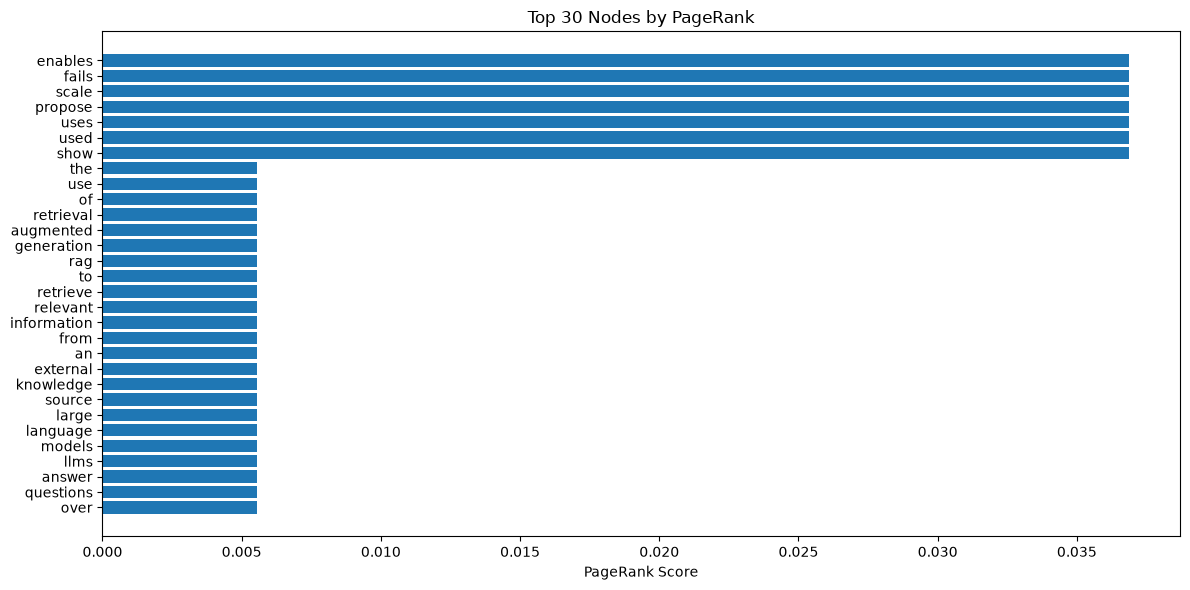

In [17]:
top_pr = sorted(centrality["pagerank"].items(), key=lambda x: x[1], reverse=True)[:30]
top_pr_nodes = [n for n, _ in top_pr]
top_pr_scores = [s for _, s in top_pr]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top_pr_nodes)), top_pr_scores)
ax.set_yticks(range(len(top_pr_nodes)))
ax.set_yticklabels(top_pr_nodes)
ax.set_xlabel("PageRank Score")
ax.set_title("Top 30 Nodes by PageRank")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

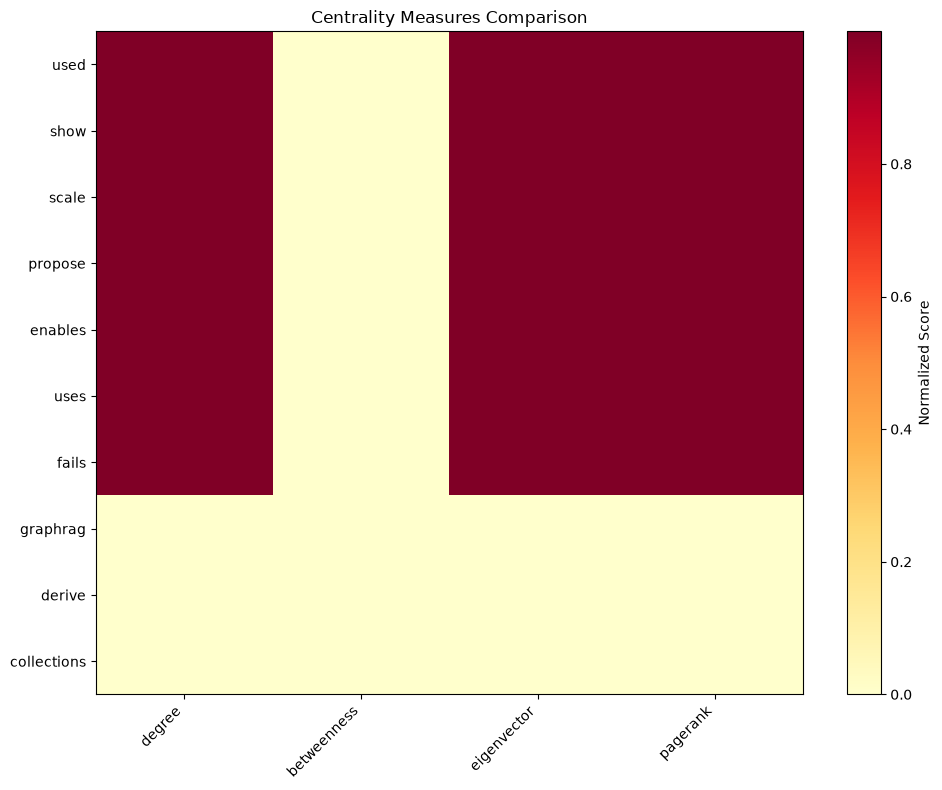

In [18]:
top_nodes = list(mci_top[:15])
metrics_to_compare = ["degree", "betweenness", "eigenvector", "pagerank"]

data_matrix = []
for node in top_nodes:
    row = []
    for metric in metrics_to_compare:
        val = centrality[metric].get(node, 0)
        row.append(val)
    data_matrix.append(row)

data_matrix = np.array(data_matrix)
data_norm = (data_matrix - data_matrix.min(axis=0)) / (data_matrix.max(axis=0) - data_matrix.min(axis=0) + 1e-10)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(data_norm, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(metrics_to_compare)))
ax.set_xticklabels(metrics_to_compare, rotation=45, ha="right")
ax.set_yticks(range(len(top_nodes)))
ax.set_yticklabels(top_nodes)
plt.colorbar(im, ax=ax, label="Normalized Score")
ax.set_title("Centrality Measures Comparison")
plt.tight_layout()
plt.show()

## 9. Conclusions

### Key Findings:

1. **TextRank is the most significant method** — it extracts **multi-word phrases** that directly capture the core concepts of the abstract (e.g., "global questions", "source text", "private text", "community summaries"). These phrases are meaningful, interpretable, and closely aligned with the paper's key contributions.

2. **Centrality Measures (MCI)** identify **single-word hubs** ("graph", "model", "data") that are structurally important in the dependency graph but lack the semantic specificity of TextRank phrases. Useful as a complementary signal, not as a primary extraction method.

3. **Louvain Communities** reveal **thematic clusters** of co-occurring words. While useful for grouping related concepts, the communities are dominated by common stopword-like nodes and require further filtering to be actionable.

### Why TextRank wins:

- Produces **readable, compound phrases** that a human would recognize as topics
- Captures **domain-specific terminology** ("retrieval-augmented generation", "knowledge graph")
- Ranks by **co-occurrence importance**, which correlates with semantic relevance
- Requires **no post-processing** — results are immediately useful as topic seeds

### Recommendation for KGraph:

**Primary method: TextRank** for extracting topic phrases from document abstracts.

Optional enhancements:
- Use **centrality** to weight/filter TextRank phrases by structural importance
- Use **Louvain** only if community-level grouping is needed (e.g., for hierarchical topic organization)

TextRank alone provides the most actionable and interpretable output for knowledge graph seed extraction.